In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
from scipy.integrate import solve_bvp, simpson
import time

newparams = {'figure.figsize': (6.0, 6.0), 'axes.grid': True,
 'lines.markersize': 6, 'lines.linewidth': 2,
 'font.size': 10}
plt.rcParams.update(newparams)

## Oppgave 1

### 1a)

For å løse initialverdiproblemet
<br><br>
$$
    \frac{d^2 y}{dx^2} = -4 \sin(2x),
$$
<br><br>
med startbetingelsene:
<br><br>
$$
    y(0) = 0, \quad y'(0) = 2.
$$
<br><br>
analytisk, er det mulig å integrere to ganger over problemet for å finne løsningen
<br><br>
$$
    \frac{dy}{dx} = \int -4 \sin(2x) \, dx
$$

$$
    = -4 \cdot \left(-\frac{1}{2} \cos(2x)\right) + C_1
$$

$$
    = 2 \cos(2x) + C_1.
$$

$$
    y = \int \left(2 \cos(2x) + C_1 \right) dx
$$

$$
    = 2 \cdot \frac{1}{2} \sin(2x) + C_1 x + C_2
$$

$$
    = \sin(2x) + C_1 x + C_2.
$$
<br><br>
Deretter løser man for initialbetingelsene. Startbetingelsen gir $ y(0) = 0 $ 
<br><br>
$$
    0 = \sin(0) + C_1(0) + C_2 \quad \Rightarrow \quad C_2 = 0.
$$
<br><br>
Videre er det oppgitt at $ y'(0) = 2 $ 
<br><br>
$$
    2 = 2 \cos(0) + C_1
$$

$$
    2 = 2(1) + C_1
$$

$$
    C_1 = 0.
$$
<br><br>
Løsningen av initialverdiproblemet blir dermed
<br><br>
$$
    y(x) = \sin(2x).
$$



### 1b)

Det er ønsket å skrive om andreordens differensiallikningen fra oppgave 1a) om til en førsteordens differensialligning for vektor 

<br><br>
$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}
$
<br><br>

Det vil være hensiktsmessig å sette $ y(x)=y_1(x) $, og $y'(x)=y_2(x)$ for å skrive om til et førsteordens system. 
Dermed blir

<br><br>
$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}= \begin{pmatrix} {y_1}(x) \\ {y_2}(x)\end{pmatrix}
$
<br><br>

Det gir videre $ y_1(x)'=y'(x)=y_2(x) $ og $y_2'(x)=y''(x)=-4\sin(2x)$ som resulterer i første ordens system

<br><br>
$
\vec{y}(x) = \begin{pmatrix} {y}(x) \\ {y'}(x)\end{pmatrix}= \begin{pmatrix} {y_1}(x) \\ {y_2}(x)\end{pmatrix}= \begin{pmatrix} {y_2}(x) \\ {-4\sin}(2x)\end{pmatrix}
$
<br><br>

Dette kan kombineres med de kjente initialverdiene

<br><br>
$
\vec{y}(0) = \begin{pmatrix} {y}(0) \\ {y'}(0)\end{pmatrix}=\begin{pmatrix} 0\\2\end{pmatrix}
$
<br><br>

Som resulterer i

<br><br>
$
\vec{y}(x) = \begin{pmatrix} {y_1'}(x)={y_2}(x) \\ {y_2'}(x)={-4\sin}(2x) \\ {y_1}(0)=0, \quad  {y_2}(0)=2 \end{pmatrix} 
$



### 1c)

In [2]:
def f(x, y):
    return np.array([y[1], -4*np.sin(2*x)]) 


In [6]:
def rk(x0, xend, y0, f, h0, tol, alpha):
    x = x0
    h = h0
    y = y0.copy()

    accepted=0
    rejected=0 

    X=[x]
    Y=[y]
    H=[]
    k1 = f(x,y)


    while x < xend:
        h = min(h, xend - x)
        k2 = f(x + 0.5 * h, y + 0.5 * h * k1)
        k3 = f(x + 0.75 * h, y + 0.75 * h * k2)

        ynext = y + 1/9 * h * (2 * k1 +3 * k2 +4 * k3)
        k4 = f(x + h, ynext)
        znext = y + 1/24 * h * (7 * k1 + 6 * k2 + 8 * k3 + 3 * k4)
        est = np.linalg.norm(ynext - znext)

        if est < tol: # sjekker om algoritmen kan bruke steget
            k1 = k4
            x = x + h
            y = ynext # y eller z
            X.append(x)
            Y.append(y.copy())
            H.append(h)

            accepted +=1
        else:
            rejected += 1 #forkastede steg der feilestimatet var for stort
        
        if est == 0:
            h = 2*h
        else:
            h = alpha*h*(tol/est)**(1/3)

    Xa = np.array(X)
    Ya = np.array(Y)
    Ha=np.array(H)

    stats = {"Accepted steps": accepted, "Discarded steps": rejected}
    return Xa, Ya, Ha, stats

{'Accepted steps': 1070, 'Discarded steps': 1}


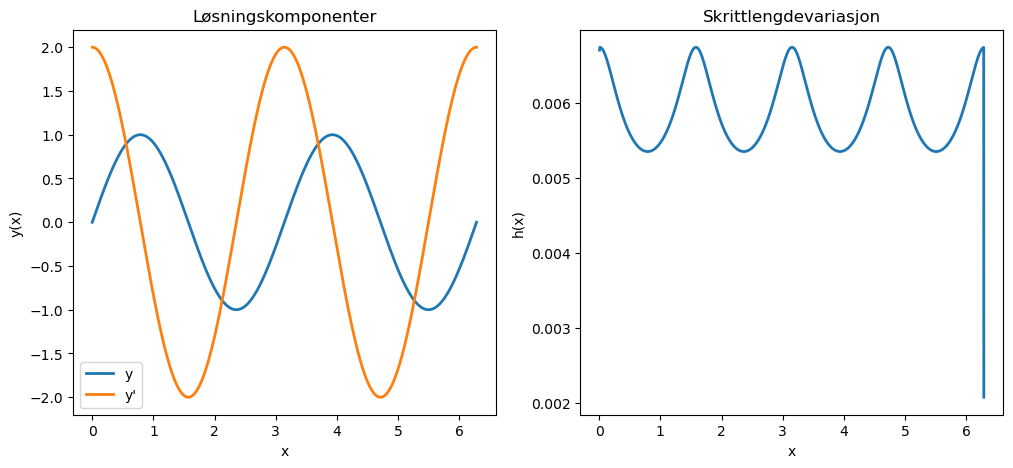

In [9]:
#initialbetingelser
x0 = 0.0
y0 = np.array([0.0, 2.0])
xend = 2 * np.pi
alpha = 0.8
tol = 1e-7
h0 = 0.1
Xa, Ya, Ha, stats = rk(x0, xend, y0, f, h0, tol,alpha)

print(stats)

plt.figure(figsize=(12, 5)) 

plt.subplot(1, 2, 1) 
plt.plot(Xa, Ya[:, 0], label = "y")
plt.plot(Xa, Ya[:, 1], label = "y'")
plt.title("Løsningskomponenter")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(Xa[1:], np.diff(Xa))
plt.title("Skrittlengdevariasjon")
plt.xlabel("x")
plt.ylabel("h(x)")
plt.grid()
plt.show()

Feilestimatet og oppdateringen av steglengden er gitt ved

$$
\mathrm{est}_{n+1} = \left\lVert \vec{y}_{n+1} - \vec{z}_{n+1} \right\rVert
$$

og

$$
h_{\mathrm{new}} = \alpha h_n \left(\frac{\mathrm{tol}}{\mathrm{est}}\right)^{1/3}.
$$

Figuren for løsningskomponentene viser at løsningene oppfører seg som forventet. Fra oppgave 1a vet vi at den eksakte løsningen er

$$
y(x) = \sin(2x), \qquad y'(x) = 2\cos(2x),
$$

og plottet fra koden følger denne periodiske oppførselen. Kjøringen ga 1070 aksepterte steg og 1 forkastet steg.

Plottet av steglengden viser at skrittlengden varierer periodisk med $x$. Dette skyldes at løsningen noen steder endrer seg raskere enn andre. Når løsningen varierer raskt, blir feilestimatet $\mathrm{est}_{n+1}$ større, og da må metoden redusere steglengden for å holde feilen under toleransen. Når løsningen varierer langsommere, blir feilestimatet mindre, og steglengden kan økes. Derfor blir steglengden minst der løsningen krummer mest, og størst der løsningen varierer mer rolig.


sammenlign/lag tabell med ulike alpha og tol for å se hvor mange steg man får

### 1d)